# Experiment Design

**Philosophy:** Pattern-first, interview-oriented. Each section answers a question an interviewer would ask. §0 covers the foundational definitions interviewers probe verbatim ("explain a p-value to a PM"); everything after is design patterns.

---

## Decision Table

| If you need to... | Go to |
| :--- | :--- |
| Nail the definition questions (p-value, CI, Type I/II, SUTVA) | §0 — Foundations |
| Walk through designing a test end-to-end | §1 — Design Checklist |
| Choose what to measure | §2 — Metric Selection |
| Decide what to randomize, and who actually gets exposed | §3 — Unit of Randomization & Exposure |
| Calculate how long to run the test (any design) | §4 — Power Analysis & Sample Size |
| Verify the experiment is set up correctly + platform mechanics | §5 — Validity Checks & Infrastructure |

In [1]:
# ── Shared dark plot theme (used by all plots in these notebooks) ────────────
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

BG, PANEL, GRID = '#0b0e14', '#13171f', '#1e2433'
TXT, MUT = '#d4dbe8', '#6b7a99'
CYAN, AMBER, GREEN, RED, PURPLE = '#4fc4cf', '#f0c674', '#7ec98a', '#f76f6f', '#b294bb'

def dark_fig(nrows=1, ncols=1, figsize=(12, 4)):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.patch.set_facecolor(BG)
    for ax in np.ravel(axes):
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=MUT)
        ax.spines[:].set_color(GRID)
        ax.grid(True, alpha=0.2, color=GRID)
    return fig, axes

def style_labels(ax, xlabel=None, ylabel=None, title=None):
    if xlabel: ax.set_xlabel(xlabel, color=TXT)
    if ylabel: ax.set_ylabel(ylabel, color=TXT)
    if title:  ax.set_title(title, color=TXT, fontsize=11)

def dark_legend(ax, **kw):
    ax.legend(labelcolor=TXT, facecolor=PANEL, edgecolor=GRID, fontsize=9, **kw)

---
## §0 — Foundations

The definitions interviewers ask for verbatim. Get these *precisely* right — the wrong phrasings below are the most common screen-out mistakes.

### Potential Outcomes (Neyman–Rubin)

Every unit *i* has two potential outcomes: **Y_i(1)** if treated, **Y_i(0)** if not. The individual treatment effect is `Y_i(1) − Y_i(0)`.

**The fundamental problem of causal inference:** we only ever observe *one* of the two — the other is the **counterfactual**. Causal inference is a missing-data problem.

```
ATE = E[Y(1) − Y(0)]          ← what we want
Naive diff = E[Y | T=1] − E[Y | T=0]   ← what we can compute

Naive diff = ATE  +  selection bias
                     (E[Y(0)|T=1] − E[Y(0)|T=0] — treated and untreated
                      differ even without treatment)
```

**Why randomization works:** random assignment makes T independent of (Y(1), Y(0)), so `E[Y(0)|T=1] = E[Y(0)|T=0]` — selection bias is zero *by design* and the difference in means is an unbiased ATE estimate.

### SUTVA — the assumption people forget A/B tests have

**S**table **U**nit **T**reatment **V**alue **A**ssumption, two parts:

1. **No interference** — unit i's outcome doesn't depend on other units' assignments. Violated by: social features, marketplaces (treated buyers deplete shared supply), shared resources. → fix with cluster/switchback designs (§3).
2. **One version of treatment** — "treatment" is the same thing for everyone. Violated by: rollout bugs on some devices, inconsistent feature behavior.

When an interviewer asks *"what assumptions does an A/B test make?"* — SUTVA is the expected answer, with a network-effects example.

### Type I / Type II Errors, α, Power

| | H₀ true (no effect) | H₀ false (real effect) |
| :--- | :--- | :--- |
| **Reject H₀** | Type I error — prob. **α** (false positive) | Correct — prob. **1−β** = **power** |
| **Fail to reject** | Correct — prob. 1−α | Type II error — prob. **β** (false negative) |

Standard: α = 0.05, power = 0.80 → you accept a 5% false-positive rate and a 20% chance of *missing* a true effect of exactly the MDE size.

### p-value — the precise definition

> The probability of observing a result **at least as extreme** as the one observed, **assuming the null hypothesis is true**.

It is a statement about the data given H₀ — *never* about H₀ given the data.

| ❌ Wrong (instant red flag) | Why it's wrong |
| :--- | :--- |
| "p is the probability the null is true" | That's P(H₀ \| data) — requires Bayes + a prior |
| "p = 0.03 means 3% chance the result is due to chance" | Same inversion, different words |
| "1 − p is the probability the effect is real" | No — p says nothing about P(effect) |
| "p = 0.06 means there is no effect" | Absence of evidence ≠ evidence of absence; check power |

**"Explain a p-value to a PM":** *"If the feature truly did nothing, a p-value of 0.03 means there'd only be a 3% chance of seeing a difference this large just from random noise. It's small enough that noise is an unlikely explanation — it does not mean there's a 97% chance the feature works."*

### Confidence interval — the precise definition

> A 95% CI is produced by a **procedure** that, over many repeated experiments, captures the true effect 95% of the time.

For any *single* computed interval, the true effect is either in it or not — there is no 95% probability attached to one realized interval (that's a Bayesian credible interval). The simulation below makes this concrete: the *procedure* has 95% coverage; individual intervals just hit or miss.

Coverage: 96 / 100 intervals contain the true mean (96%) — by design ≈ 95%


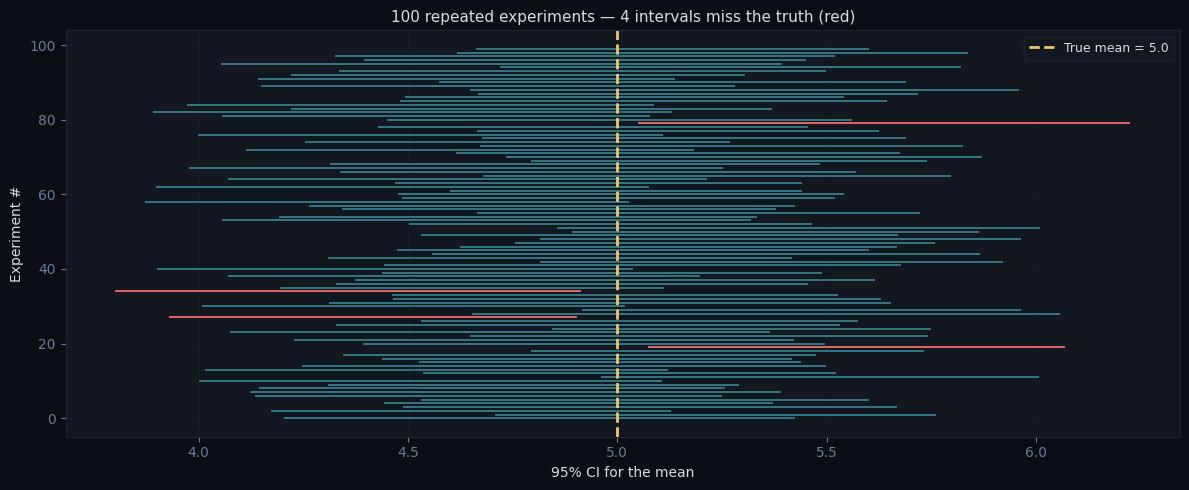

In [2]:
# ── What "95% confidence" actually means: coverage of the PROCEDURE ─────────
np.random.seed(7)
true_mu, sigma, n, n_sims = 5.0, 2.0, 50, 100

lo, hi = np.empty(n_sims), np.empty(n_sims)
for i in range(n_sims):
    x = np.random.normal(true_mu, sigma, n)
    se = x.std(ddof=1) / np.sqrt(n)
    lo[i], hi[i] = x.mean() - 1.96 * se, x.mean() + 1.96 * se

miss = (true_mu < lo) | (true_mu > hi)
print(f"Coverage: {(~miss).sum()} / {n_sims} intervals contain the true mean "
      f"({(~miss).mean():.0%}) — by design ≈ 95%")

fig, ax = dark_fig(figsize=(12, 5))
order = np.arange(n_sims)
for i in order:
    c = RED if miss[i] else CYAN
    ax.plot([lo[i], hi[i]], [i, i], color=c, lw=1.4, alpha=0.9 if miss[i] else 0.55)
ax.axvline(true_mu, color=AMBER, lw=2, ls='--', label=f'True mean = {true_mu}')
style_labels(ax, xlabel='95% CI for the mean', ylabel='Experiment #',
             title=f'100 repeated experiments — {miss.sum()} intervals miss the truth (red)')
dark_legend(ax)
plt.tight_layout(); plt.show()

---
## §1 — The Design Checklist

When an interviewer says *"walk me through how you'd design an experiment"*, this is the sequence they expect.

```
1. Define the question        What decision will this experiment inform?
2. Identify the unit          What gets randomized? (user, session, page, cluster)
   ... and the exposure       Who actually triggers the feature? (§3 — dilution)
3. Choose metrics             Primary metric + guardrail metrics
4. Determine sample size      Power analysis → minimum detectable effect → duration
5. Design randomization       Simple, stratified, or cluster?
6. Set the stopping rule      Fixed horizon or sequential? Decide BEFORE launching.
7. Run the experiment         Full weeks, no peeking
8. Analyze                    SRM check → balance check → ATE + CI → segments
9. Recommend                  Effect size + confidence + business impact → decision
```

**Interviewer follow-ups to prepare for:**

| Question | Key point in your answer |
| :--- | :--- |
| How long would you run it? | Power analysis — not "until significance" |
| What if the primary metric doesn't move? | Distinguish no effect vs underpowered |
| What if two metrics move in opposite directions? | Guardrail triggered — do not ship |
| How do you handle novelty effect? | Run for multiple weeks, check if effect decays |
| What if users in both groups interact? | Network effect (SUTVA violation) — cluster randomization |
| What if only a few users ever see the feature? | Trigger analysis — dilution changes power math (§3, §4) |

---
## §2 — Metric Selection

Choosing the wrong metric is one of the most common interview failure points. The metric must be **sensitive** (moves when the treatment works), **attributable** (caused by the treatment, not confounders), and **not gameable** (can't be optimized without delivering real value).

### The Metric Hierarchy

```
North Star Metric
│  Long-run business goal — moves slowly, hard to optimize directly
│  Example: annual revenue, DAU, LTV
│
├── Primary Metric (OEC — Overall Evaluation Criterion)
│   What this experiment is designed to move
│   Must be: sensitive enough to detect effect in the experiment window
│   Example: 7-day retention, checkout conversion rate, session length
│
├── Guardrail Metrics
│   Must NOT move (or must not move negatively)
│   Protect against shipping something that wins locally but hurts globally
│   Example: latency, crash rate, revenue per user, unsubscribe rate
│
└── Diagnostic / Debug Metrics
    Help explain WHY the primary metric moved (or didn't)
    Not used for the ship/no-ship decision
    Example: click-through rate, funnel step completion rates
```

### Counter-metrics — the "what could this break?" question

For every primary metric, name the behavior you might be cannibalizing and add a counter-metric for it. Pattern: *push notifications ↑ sessions* → counter: unsubscribe / uninstall rate. *Aggressive upsell ↑ revenue per order* → counter: repeat purchase rate. Interviewers often phrase this as *"how would you know if you're winning the metric but losing the user?"*

### The "design metrics for feature X" pattern

```
1. State the feature's intent in one sentence (what user behavior should change?)
2. Primary  = closest measurable expression of that behavior, movable in 2–4 weeks
3. Guardrails = the 2–3 things the feature could plausibly damage
4. Counter-metric = the cannibalization risk
5. Diagnostics = funnel steps that explain the mechanism
```

### Good vs Bad Primary Metric

| Property | Good | Bad |
| :--- | :--- | :--- |
| Sensitivity | Moves within experiment window | Takes months to show signal (LTV) |
| Attributability | Directly caused by the feature | Influenced by many external factors |
| Not gameable | Hard to inflate without real value | Clicks, impressions (easy to fake) |
| Directional | Clearly higher = better | Ambiguous direction |

### Common Metric Mistakes

- **Vanity metrics** — total page views looks good but doesn't reflect value; use unique users or session depth instead
- **Proxy too far from the North Star** — optimizing click rate may hurt purchase rate downstream
- **Ratio metrics with unequal denominators** — average revenue per user can move just because user composition shifts; check both numerator and denominator (demo below)
- **Testing too many primary metrics** — multiple testing inflates false positives; pick one primary metric and pre-register it

In [3]:
# ── Ratio-metric trap: ARPU moves with ZERO change in anyone's spending ─────
# Treatment makes signup easier → attracts extra casual users.
# Every user type spends exactly the same in both groups.

casual_spend, power_spend = 1.0, 20.0

ctrl_casual, ctrl_power = 8_000, 2_000       # control: 20% power users
trt_casual,  trt_power  = 11_000, 2_000      # treatment: +3k casual users, same power users

for name, n_c, n_p in [('Control  ', ctrl_casual, ctrl_power),
                       ('Treatment', trt_casual,  trt_power)]:
    revenue = n_c * casual_spend + n_p * power_spend
    users   = n_c + n_p
    print(f"{name}: revenue ${revenue:>8,.0f} | users {users:>6,} "
          f"| ARPU ${revenue/users:.2f}")

print()
print("ARPU fell from $4.80 to $3.69 (−23%) — yet no user spends less, and")
print("total revenue went UP. The denominator (user mix) shifted.")
print("Lesson: for ratio metrics, always decompose into numerator + denominator")
print("before interpreting. (Variance of ratio metrics: delta method, Analysis §2.)")

Control  : revenue $  48,000 | users 10,000 | ARPU $4.80
Treatment: revenue $  51,000 | users 13,000 | ARPU $3.92

ARPU fell from $4.80 to $3.69 (−23%) — yet no user spends less, and
total revenue went UP. The denominator (user mix) shifted.
Lesson: for ratio metrics, always decompose into numerator + denominator
before interpreting. (Variance of ratio metrics: delta method, Analysis §2.)


---
## §3 — Unit of Randomization & Exposure

The unit of randomization is what gets assigned to treatment or control. Choosing the wrong unit causes **false positives** (analysis unit finer than randomization unit) or **infeasibility** (user-level when the treatment affects the whole platform).

### Units and When to Use Each

| Unit | Use when | Risk |
| :--- | :--- | :--- |
| **User** | Feature is user-specific, most common default | Users interact with each other → spillover |
| **Session** | Feature only affects a single visit | Same user can be in both groups → contamination |
| **Page / Request** | Server-side rendering change, no memory needed | Very high contamination risk |
| **Cluster** (geo, device, cohort) | Network effects, social features, marketplace | Lower statistical power, complex analysis |
| **Time** (switchback) | Marketplace / supply-demand coupling | Carryover effects between periods |

### Choosing the unit: a decision rule

The table above lists the options; this is how you actually pick one. Ask these in order — the **first** condition that fires sets a floor on how coarse the unit must be, and you never go finer than that floor.

```
1. Causal scope     Does the treatment change the UNIT's persistent state
                    (memory, habit, account settings, what they'll see next)?
                    → Yes: randomize by USER. A user must get one experience.

2. Interference     Do treated units affect untreated ones (social graph,
   (SUTVA)          marketplace supply/demand, shared inventory)?
                    → Yes: go coarser — CLUSTER (geo, cohort) or TIME (switchback),
                      coarse enough that the groups don't leak into each other.

3. Denominator      Is the analysis unit (the metric's denominator) finer than
                    the randomization unit? (e.g. randomize users, measure per-session)
                    → Allowed, but you MUST aggregate to the randomization unit or
                      use cluster-robust SEs — never a naive per-row test.
                      Rule: randomization unit ≥ analysis unit, always.

4. Consistency &    Would a unit seeing DIFFERENT variants across visits be confusing,
   novelty          or would one exposure change later behavior (learning, habit)?
                    → Yes: USER, so assignment is stable across sessions.

5. Power budget     Only after 1–4 are satisfied: finer units give more samples and
                    more power, but the gain is real only when units are independent
                    and carryover-free. Coarser units (clusters) cost power — budget
                    for more clusters, not more users.
```

### User-level vs session-level: the decision you'll be asked most

These two cover the majority of product experiments, and the choice turns on one question — *does being in treatment leave a trace on the user?*

**Randomize by USER when:**
- The experience must be **consistent across visits** — checkout flow, pricing, onboarding, navigation structure. Seeing variant A today and B tomorrow feels broken and erodes trust.
- The metric **accumulates over the user** — retention, LTV, subscription conversion, sessions-per-user.
- There's a **learning, habit, or novelty effect** — the treatment's impact builds (or fades) over repeated exposure, so a user needs a single consistent assignment to measure it.
- **Carryover is plausible** — a prior treated session would contaminate a later control session for the same user.
- The product is **logged-in** with a stable identity to assign against.

**Randomize by SESSION when:**
- Each session is a **self-contained, independent interaction** with no expectation of cross-session memory — one-off search, anonymous tool use.
- The metric is **session-scoped** — in-session conversion, task completion, clicks within a visit.
- Users are **largely anonymous** or cookies churn, so a durable user identity isn't available anyway.
- You want **more statistical power sooner** — sessions accumulate far faster than unique users — *and* you've confirmed the treatment leaves no lasting trace (otherwise the power is bought with bias).

**The decisive test:** if showing the same person two different variants across visits would feel broken — or if being in treatment *once* changes how they behave later — randomize by **user**. If each session is a genuinely fresh interaction, **session-level** is fine and buys you power. The classic trap is choosing session-level for a feature that touches user state: it contaminates the estimate (bias) *and*, if then analyzed per session, inflates false positives — the two failure modes below.

### Two distinct unit problems — don't conflate them in an interview

1. **Randomization unit too fine (session-level for a user-level feature):** the same user sees both experiences → carryover/contamination → **biased** effect estimate. Fix: randomize at the user level.
2. **Analysis unit finer than randomization unit (randomize users, t-test sessions):** sessions within a user are correlated; a naive t-test treats them as independent → **underestimated SE → inflated false positives**. Fix: aggregate to one number per user, use cluster-robust SEs, or the delta method (Analysis §2). The simulation below shows how bad this gets.

### Network Effects → Cluster Randomization

When treated users affect control users (social features, marketplaces, shared resources) — a SUTVA violation (§0):
- Assign entire clusters (cities, friend groups, cohorts) to treatment or control
- Clusters must be relatively isolated from each other
- Statistical power drops — need more clusters, not just more users (ICC math in §4)
- Analysis: cluster-robust standard errors or mixed-effects models

### Stratified Randomization

When you want to ensure balance on key covariates (platform, country, user tenure):
- Randomize within strata — each stratum gets exactly 50/50 split
- Reduces variance → increases power (similar to blocking in clinical trials)
- Must analyze with stratification weights to get unbiased estimates

### Assignment vs Exposure — trigger analysis and dilution

**Assignment** = who was bucketed. **Exposure (trigger)** = who actually hit the feature's code path. If the feature only fires on the checkout page, most assigned users never see it.

```
ITT (intention-to-treat)   Compare by ASSIGNMENT. Unbiased, answers "what happens
                           if we ship?" — but the effect is diluted:
                           effect_ITT ≈ trigger_rate × effect_on_triggered

TOT / CACE                 Effect on those who actually triggered. With one-sided
                           noncompliance: effect_TOT = effect_ITT / trigger_rate.

Triggered-only analysis    Compare ONLY users who triggered, in both groups.
                           Valid only if triggering itself can't be affected by
                           treatment (otherwise you're conditioning on a
                           post-treatment variable → selection bias).
```

Dilution has a brutal power consequence: at a 20% trigger rate the ITT effect is 5× smaller, so the required sample size is **25×** larger (n scales with 1/effect², §4). The standard interview answer: *"I'd compute the trigger rate first, analyze ITT for the ship decision, and restrict to triggered users (with a counterfactual trigger check) for the mechanism."*

**Common mistakes:**
- Randomizing at the session level for features that affect user state — creates within-user contamination
- Analyzing sessions/pageviews with a naive t-test when randomization was by user — inflated false positive rate (see simulation)
- Using geo-level clusters that are not actually isolated — a user in NYC may interact with users in Boston, making clusters leaky
- Comparing triggered treatment users against ALL control users — selection bias; compare against the control users who *would have* triggered

FPR, user-level analysis (correct):       4.8%   ← ≈ nominal 5%
FPR, session-level analysis (naive):      28.7%   ← badly inflated


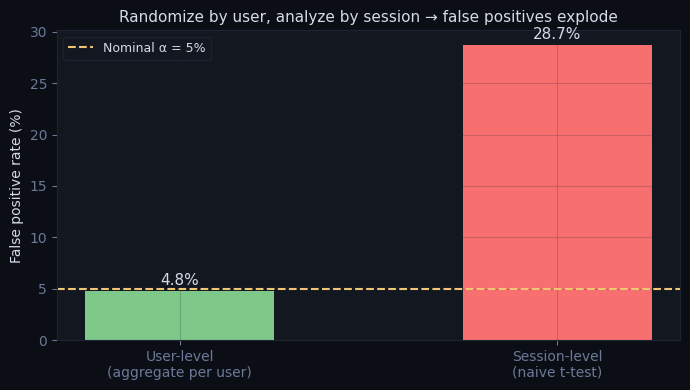

In [4]:
# ── Simulation: analysis unit finer than randomization unit → inflated FPR ──
# Users have persistent individual behavior (random effect). NO true treatment
# effect anywhere. We measure how often a t-test falsely rejects at α = 0.05.

np.random.seed(42)
n_users, n_sims = 200, 2000

def one_sim(analysis_unit):
    u = np.random.normal(0, 1.0, n_users)                 # user random effect
    n_sess = np.random.poisson(4, n_users) + 1
    uid = np.repeat(np.arange(n_users), n_sess)
    y = u[uid] + np.random.normal(0, 1.0, len(uid))       # session outcomes
    assign = np.random.rand(n_users) < 0.5                # randomize by USER
    z = assign[uid]
    if analysis_unit == 'session':                        # naive: t-test on sessions
        return stats.ttest_ind(y[z], y[~z])[1]
    df = pd.DataFrame({'uid': uid, 'y': y, 'z': z})       # correct: 1 row per user
    agg = df.groupby('uid').agg(y=('y', 'mean'), z=('z', 'first'))
    return stats.ttest_ind(agg.y[agg.z], agg.y[~agg.z])[1]

fpr = {unit: np.mean([one_sim(unit) < 0.05 for _ in range(n_sims)])
       for unit in ['user', 'session']}

print(f"FPR, user-level analysis (correct):       {fpr['user']:.1%}   ← ≈ nominal 5%")
print(f"FPR, session-level analysis (naive):      {fpr['session']:.1%}   ← badly inflated")

fig, ax = dark_fig(figsize=(7, 4))
bars = ax.bar(['User-level\n(aggregate per user)', 'Session-level\n(naive t-test)'],
              [fpr['user'] * 100, fpr['session'] * 100], color=[GREEN, RED], width=0.5)
ax.axhline(5, color=AMBER, ls='--', lw=1.5, label='Nominal α = 5%')
for b, v in zip(bars, [fpr['user'] * 100, fpr['session'] * 100]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.6, f'{v:.1f}%',
            ha='center', color=TXT, fontsize=11)
style_labels(ax, ylabel='False positive rate (%)',
             title='Randomize by user, analyze by session → false positives explode')
dark_legend(ax)
plt.tight_layout(); plt.show()

---
## §4 — Power Analysis & Sample Size

Sample size must be determined **before** the experiment runs. Running until you see significance is peeking — it inflates the false positive rate (Analysis §4).

### 4.1 — The canonical case: binary metric, 50/50 split

Baseline conversion:    10.0%
Target conversion:      10.50%
Required n per group:   57,763
Total users needed:     115,526
Duration at 5,000/day:  24 days (3.4 weeks)


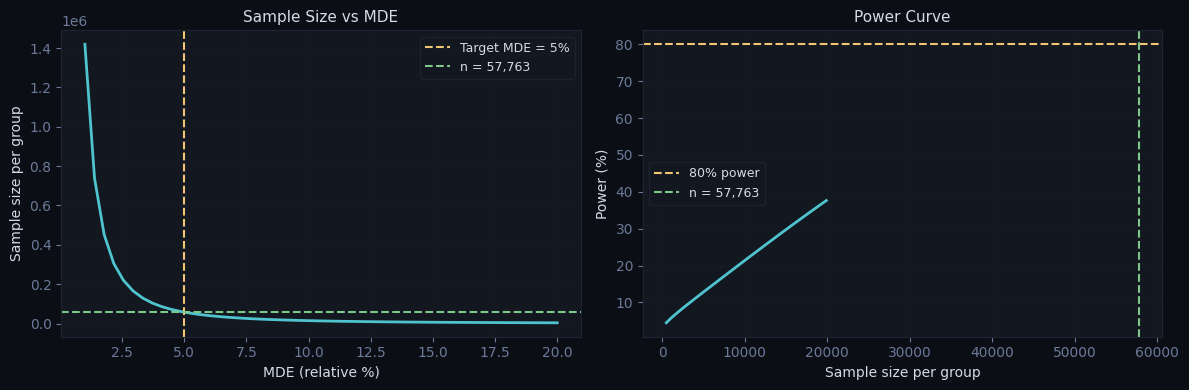

In [5]:
# ── The four inputs — fix three, solve for one ───────────────────────────────
# alpha  (α) — false positive rate — standard: 0.05
# power  (1-β) — true positive rate — standard: 0.80
# effect_size (MDE) — minimum effect worth detecting
# n — sample size per group

def sample_size_per_group(baseline, mde_relative, alpha=0.05, power=0.80):
    """
    Required sample size per group, two-sample z-test on proportions.
    baseline     : baseline conversion rate (e.g. 0.10 for 10%)
    mde_relative : minimum detectable effect as relative lift (e.g. 0.05 for +5%)
    """
    p1 = baseline
    p2 = baseline * (1 + mde_relative)
    delta = p2 - p1
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    pooled_p = (p1 + p2) / 2
    n = (z_alpha * np.sqrt(2 * pooled_p * (1 - pooled_p)) +
         z_beta  * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2 / delta**2
    return int(np.ceil(n))

# Example: checkout page redesign
baseline      = 0.10    # 10% conversion rate
mde_relative  = 0.05    # detect +5% relative lift (10% → 10.5%)
daily_traffic = 5000    # users/day exposed to the test

n = sample_size_per_group(baseline, mde_relative)
days = int(np.ceil(2 * n / daily_traffic))

print(f"Baseline conversion:    {baseline:.1%}")
print(f"Target conversion:      {baseline*(1+mde_relative):.2%}")
print(f"Required n per group:   {n:,}")
print(f"Total users needed:     {2*n:,}")
print(f"Duration at {daily_traffic:,}/day:  {days} days ({days/7:.1f} weeks)")

# ── MDE curve + power curve ──────────────────────────────────────────────────
mde_values = np.linspace(0.01, 0.20, 50)
n_values   = [sample_size_per_group(baseline, m) for m in mde_values]

fig, axes = dark_fig(1, 2)
axes[0].plot(mde_values * 100, n_values, color=CYAN, lw=2)
axes[0].axvline(mde_relative * 100, color=AMBER, ls='--', lw=1.5,
                label=f'Target MDE = {mde_relative:.0%}')
axes[0].axhline(n, color=GREEN, ls='--', lw=1.5, label=f'n = {n:,}')
style_labels(axes[0], 'MDE (relative %)', 'Sample size per group', 'Sample Size vs MDE')
dark_legend(axes[0])

n_range = np.arange(500, 20000, 200)
p1, p2  = baseline, baseline * (1 + mde_relative)
se_vals = np.sqrt(p1*(1-p1)/n_range + p2*(1-p2)/n_range)
power_vals = stats.norm.cdf((p2 - p1) / se_vals - stats.norm.ppf(0.975))
axes[1].plot(n_range, power_vals * 100, color=CYAN, lw=2)
axes[1].axhline(80, color=AMBER, ls='--', lw=1.5, label='80% power')
axes[1].axvline(n,  color=GREEN, ls='--', lw=1.5, label=f'n = {n:,}')
style_labels(axes[1], 'Sample size per group', 'Power (%)', 'Power Curve')
dark_legend(axes[1])
plt.tight_layout(); plt.show()

### 4.2 — Continuous metrics

For continuous metrics (revenue per user, session length) the formula needs the metric's **standard deviation σ**, which you estimate from historical data — the part interviewers probe: *"where does σ come from?"* Answer: pull the metric for the same population over a recent comparable window and compute its SD (and check stability across weeks). High-variance metrics like revenue are why revenue experiments are chronically underpowered — and why variance reduction (CUPED, Analysis §3) matters.

In [6]:
def sample_size_continuous(sigma, mde_abs, alpha=0.05, power=0.80):
    """n per group for a two-sample t-test: n = 2σ²(z_α/2 + z_β)² / δ²"""
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return int(np.ceil(2 * (sigma * z / mde_abs)**2))

# Step 1: estimate σ from historical data (here: simulated 4-week pull)
np.random.seed(0)
hist = np.random.lognormal(mean=1.0, sigma=1.1, size=50_000)   # revenue/user, skewed
sigma_hat = hist.std(ddof=1)

# Step 2: pick an MDE worth caring about
mu_hat  = hist.mean()
mde_abs = 0.03 * mu_hat                  # +3% relative lift on the mean

n_cont = sample_size_continuous(sigma_hat, mde_abs)
print(f"Historical mean: ${mu_hat:.2f}   SD: ${sigma_hat:.2f}   CV = {sigma_hat/mu_hat:.1f}")
print(f"MDE (absolute):  ${mde_abs:.2f}  (+3% relative)")
print(f"n per group:     {n_cont:,}")
print()
print(f"Same setup with Winsorized metric (cap at P99): ", end="")
w = np.minimum(hist, np.quantile(hist, 0.99))
print(f"σ drops {sigma_hat:.2f} → {w.std(ddof=1):.2f}, "
      f"n drops to {sample_size_continuous(w.std(ddof=1), 0.03*w.mean()):,}")

Historical mean: $4.93   SD: $7.40   CV = 1.5
MDE (absolute):  $0.15  (+3% relative)
n per group:     39,319

Same setup with Winsorized metric (cap at P99): σ drops 7.40 → 5.89, n drops to 26,881


### 4.3 — Real-world adjustments: dilution, clusters, unequal allocation

Three corrections that turn a textbook power calculation into a credible one. All three are plotted below.

**(a) Trigger rate / dilution.** If only a fraction `r` of assigned users trigger the feature, the ITT effect is `r × δ`, so per-group n scales by **1/r²**. (Alternative: power on the *triggered* population — same n of triggered users, but you must wait `1/r` times longer to collect them.)

**(b) Cluster randomization.** Outcomes within a cluster are correlated (ICC = intra-cluster correlation). The **design effect** `DE = 1 + (m − 1) × ICC` (m = avg units per cluster) inflates required n: `n_clustered = n_simple × DE`. Even tiny ICCs hurt when clusters are large — and power is driven by the **number of clusters**, not users per cluster.

**(c) Unequal allocation.** Variance of the difference ∝ `1/n_t + 1/n_c`. Relative to 50/50, a `q : (1−q)` split needs `0.25 / (q(1−q))` times the total traffic for equal power — a 90/10 split costs 2.78× the total sample.

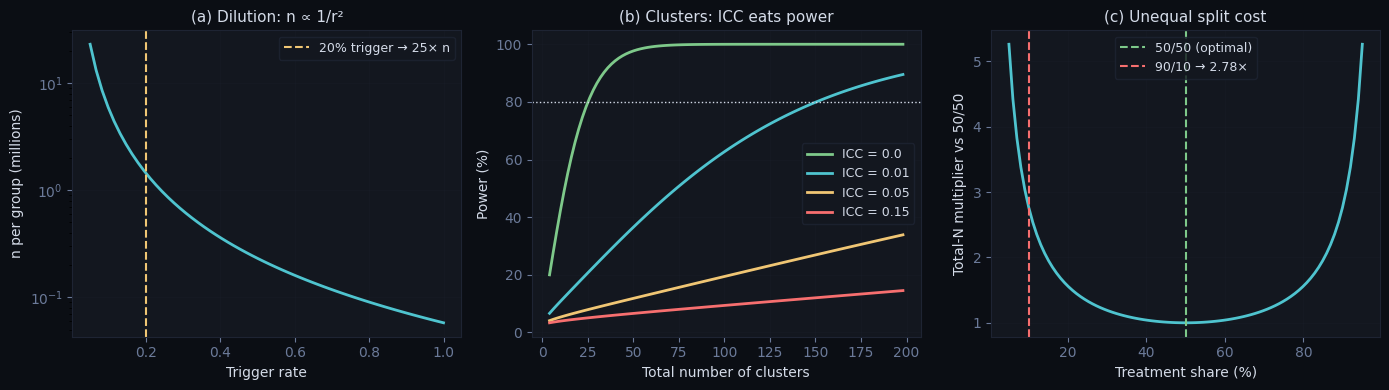

Design effect, m=500, ICC=0.01:  DE = 5.99 → ~6× more users needed


In [7]:
fig, axes = dark_fig(1, 3, figsize=(14, 4))

# (a) dilution: n_assigned per group vs trigger rate (ITT analysis)
r_grid = np.linspace(0.05, 1.0, 60)
n_base = sample_size_per_group(0.10, 0.05)          # n if everyone triggered
axes[0].plot(r_grid, n_base / r_grid**2 / 1e6, color=CYAN, lw=2)
axes[0].axvline(0.2, color=AMBER, ls='--', lw=1.5, label='20% trigger → 25× n')
style_labels(axes[0], 'Trigger rate', 'n per group (millions)', '(a) Dilution: n ∝ 1/r²')
axes[0].set_yscale('log'); dark_legend(axes[0])

# (b) clusters: power vs number of clusters, fixed cluster size m=500
def power_clustered(K, m, icc, sigma=1.0, delta=0.05):
    de   = 1 + (m - 1) * icc
    n_eff = (K * m / 2) / de                         # effective n per group
    se   = sigma * np.sqrt(2 / n_eff)
    return stats.norm.cdf(delta / se - stats.norm.ppf(0.975))

K_grid = np.arange(4, 200, 2)
for icc, c in [(0.0, GREEN), (0.01, CYAN), (0.05, AMBER), (0.15, RED)]:
    axes[1].plot(K_grid, [power_clustered(K, 500, icc) * 100 for K in K_grid],
                 color=c, lw=2, label=f'ICC = {icc}')
axes[1].axhline(80, color=TXT, ls=':', lw=1)
style_labels(axes[1], 'Total number of clusters', 'Power (%)',
             '(b) Clusters: ICC eats power')
dark_legend(axes[1])

# (c) allocation: total-traffic multiplier vs treatment share
q = np.linspace(0.05, 0.95, 90)
axes[2].plot(q * 100, 0.25 / (q * (1 - q)), color=CYAN, lw=2)
axes[2].axvline(50, color=GREEN, ls='--', lw=1.5, label='50/50 (optimal)')
axes[2].axvline(10, color=RED, ls='--', lw=1.5, label='90/10 → 2.78×')
style_labels(axes[2], 'Treatment share (%)', 'Total-N multiplier vs 50/50',
             '(c) Unequal split cost')
dark_legend(axes[2])
plt.tight_layout(); plt.show()

print(f"Design effect, m=500, ICC=0.01:  DE = {1 + 499*0.01:.2f} → ~6× more users needed")

### 4.4 — Planning with CUPED, solving for MDE, and simulation-based power

**CUPED-aware planning.** If a pre-experiment covariate correlates with the outcome at ρ, CUPED (Analysis §3) cuts variance by ρ², so `n_adjusted ≈ n × (1 − ρ²)` — plan the experiment *assuming* the adjustment. ρ = 0.7 → ~half the sample (or half the duration).

**The inverse problem.** Often traffic is fixed and the real question is *"what's the smallest effect we could detect in 4 weeks?"* — same equation, solved for MDE. If that MDE is bigger than any plausible effect, the experiment isn't worth running — a strong thing to say in an interview.

**Simulation-based power — the universal fallback.** Closed forms exist only for clean designs. For skewed metrics, Mann–Whitney, ratio metrics, or clustered data, the honest method: simulate data under the assumed effect, run your *actual* analysis pipeline many times, count rejections. Works for any design, and doubles as a check on your analytic formula.

In [8]:
# ── CUPED-aware planning ─────────────────────────────────────────────────────
rho = 0.7
print(f"n without CUPED: {n_cont:,}   with CUPED (ρ={rho}): "
      f"{int(n_cont * (1 - rho**2)):,}  ({1 - rho**2:.0%} of original)")

# ── Inverse problem: fixed traffic → solve for MDE ───────────────────────────
def mde_given_n(n_per_group, sigma, alpha=0.05, power=0.80):
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return z * sigma * np.sqrt(2 / n_per_group)

n_fixed = 4 * 7 * daily_traffic // 2                  # 4 weeks of traffic, per group
mde_min = mde_given_n(n_fixed, sigma_hat)
print(f"\nWith {n_fixed:,}/group in 4 weeks, smallest detectable lift on revenue: "
      f"${mde_min:.2f} ({mde_min/mu_hat:.1%} relative)")
print("→ if plausible effects are smaller than this, don't run the test as designed.")

# ── Simulation-based power: works for ANY metric + ANY test ─────────────────
def simulate_power(gen_data, test, n_sims=500, alpha=0.05):
    """gen_data() → (ctrl, trt) arrays; test(c, t) → p-value."""
    rej = sum(test(*gen_data()) < alpha for _ in range(n_sims))
    return rej / n_sims

np.random.seed(1)
n_grp, lift = 3000, 1.05
gen = lambda: (np.random.lognormal(1.0, 1.1, n_grp),
               np.random.lognormal(1.0 + np.log(lift), 1.1, n_grp))

p_t  = simulate_power(gen, lambda c, t: stats.ttest_ind(t, c)[1])
p_mw = simulate_power(gen, lambda c, t: stats.mannwhitneyu(t, c)[1])
print(f"\nSimulated power @ n={n_grp:,}/group, +5% lift on lognormal revenue:")
print(f"  t-test:         {p_t:.0%}")
print(f"  Mann-Whitney U: {p_mw:.0%}   ← rank test beats t-test on heavy-tailed data")

n without CUPED: 39,319   with CUPED (ρ=0.7): 20,052  (51% of original)

With 70,000/group in 4 weeks, smallest detectable lift on revenue: $0.11 (2.2% relative)
→ if plausible effects are smaller than this, don't run the test as designed.



Simulated power @ n=3,000/group, +5% lift on lognormal revenue:
  t-test:         24%
  Mann-Whitney U: 35%   ← rank test beats t-test on heavy-tailed data


### How to Estimate MDE in Practice

```
1. Pull baseline metric from historical data (last 4 weeks)
2. Ask: what effect is meaningful for this business decision?
   - Below MDE → not worth shipping even if real
   - At or above MDE → worth shipping if statistically significant
3. Apply the adjustments: trigger rate, clustering, allocation, CUPED
4. Check if the required sample size is feasible given traffic
   - If duration > 4–6 weeks → increase MDE, increase allocation, or
     solve the inverse problem and renegotiate
5. Round up to full weeks to avoid day-of-week bias
```

### Rules of Thumb

| Parameter | Standard | When to adjust |
| :--- | :--- | :--- |
| α (false positive rate) | 0.05 | Lower to 0.01 for high-stakes / irreversible decisions |
| Power (1-β) | 0.80 | Raise to 0.90 for high-stakes decisions |
| Traffic allocation | 50/50 | Use <50% treatment if feature is risky — and pay the traffic cost knowingly |
| Minimum duration | Full weeks | Always run at least 1–2 full weeks regardless of power |

**Common mistakes:**
- Setting MDE to the smallest effect you could *imagine* detecting, not the smallest effect worth *caring* about — produces impractically large sample sizes
- Forgetting dilution — powering for the triggered effect but analyzing ITT makes the experiment ~1/r² underpowered
- Sizing a cluster experiment with the simple formula — ICC of even 0.01 with large clusters multiplies required n severalfold
- Not accounting for the fact that you need traffic in both groups — total users needed is `2n`, not `n`
- Running for a fixed number of days that isn't a multiple of 7 — captures a biased day-of-week mix

---
## §5 — Validity Checks & Infrastructure

Run these **before looking at the primary metric**. If any check fails, stop — the experiment results are invalid.

In [9]:
# ── Check 1: Sample Ratio Mismatch (SRM) ─────────────────────────────────────
# Expected: 50/50 split. Actual split deviating significantly = broken randomization.
# Causes: bot traffic filtered differently, logging bugs, redirect issues.

def check_srm(n_control, n_treatment, expected_split=0.5, alpha=0.01):
    n_total  = n_control + n_treatment
    expected = [n_total * expected_split, n_total * (1 - expected_split)]
    chi2, p  = stats.chisquare([n_control, n_treatment], expected)
    srm      = p < alpha
    print(f"Control:   {n_control:,}  ({n_control/n_total:.2%})")
    print(f"Treatment: {n_treatment:,}  ({n_treatment/n_total:.2%})")
    print(f"Chi² = {chi2:.2f},  p = {p:.4f}")
    print(f"SRM detected: {'YES — experiment invalid' if srm else 'No'}")
    return srm

check_srm(n_control=10_012, n_treatment=9_487)   # imbalanced — SRM likely
print()
check_srm(n_control=10_021, n_treatment=9_979)   # balanced — OK

# ── Check 2: Covariate Balance (AA Check) ────────────────────────────────────
# Verify treatment and control have the same pre-experiment characteristics.

def balance_check(df, group_col, covariates):
    ctrl = df[df[group_col] == 'control']
    trt  = df[df[group_col] == 'treatment']
    rows = []
    for col in covariates:
        t_stat, p_val = stats.ttest_ind(ctrl[col].dropna(), trt[col].dropna())
        rows.append({'covariate': col, 'ctrl_mean': ctrl[col].mean(),
                     'trt_mean': trt[col].mean(), 'p_value': round(p_val, 4),
                     'imbalanced': p_val < 0.05})
    result = pd.DataFrame(rows)
    print(result.to_string(index=False))
    n_imb = result['imbalanced'].sum()
    print(f"\n{n_imb} of {len(covariates)} covariates imbalanced at p<0.05")
    if n_imb > len(covariates) * 0.05:
        print("WARNING: more imbalance than expected by chance — check randomization")
    return result

# ── Check 3: AA Test ─────────────────────────────────────────────────────────
# Run the analysis pipeline with NO treatment (both groups see control).
# If significant: the pipeline has a bug. Use historical data, not live traffic.
np.random.seed(0)
aa_ctrl = np.random.binomial(1, 0.10, 10_000)
aa_trt  = np.random.binomial(1, 0.10, 10_000)
_, p_aa = stats.ttest_ind(aa_ctrl, aa_trt)
print(f"\nAA test p-value: {p_aa:.4f}")
print(f"AA test result: {'FAIL — check analysis pipeline' if p_aa < 0.05 else 'PASS'}")

Control:   10,012  (51.35%)
Treatment: 9,487  (48.65%)
Chi² = 14.14,  p = 0.0002
SRM detected: YES — experiment invalid

Control:   10,021  (50.10%)
Treatment: 9,979  (49.90%)
Chi² = 0.09,  p = 0.7665
SRM detected: No

AA test p-value: 0.8508
AA test result: PASS


### What Each Check Catches

| Check | What it detects | Action if it fails |
| :--- | :--- | :--- |
| SRM | Broken assignment, logging bug, bot filtering | Stop experiment, investigate pipeline |
| Covariate balance | Biased randomization, self-selection | Stop experiment, check assignment mechanism |
| AA test | Inflated false positive rate in analysis | Fix analysis pipeline before running any AB test |

### How assignment actually works: hashing & bucketing

Production platforms don't store random draws — assignment is a **deterministic hash**:

```
bucket = hash(salt + ":" + user_id) mod 100      →  buckets 0–49 control, 50–99 treatment
```

Properties this buys you: (1) **deterministic** — same user always gets the same variant, no lookup table; (2) **stateless** — any server computes it; (3) **uniform** — a good hash spreads users evenly. The **salt** (usually the experiment ID) is what makes experiments independent — reusing a salt across two experiments gives them *perfectly correlated* assignments, confounding the two treatments. The demo below shows it.

**Layers / overlapping experiments:** to run many experiments at once, traffic is divided into layers — each experiment owns one layer's salt, so assignments across layers are independent and every user can be in many experiments simultaneously. Mutually exclusive experiments (two checkout redesigns that would collide) must share a layer.

**Carryover:** if bucket ranges are reused, last experiment's treatment group becomes this experiment's treatment group, and lingering effects contaminate the new test. Fix: re-salt every experiment (re-shuffles users), and consider a washout period for features with persistent effects.

In [10]:
import hashlib

def bucket(user_id, salt, n_buckets=100):
    h = hashlib.md5(f"{salt}:{user_id}".encode()).hexdigest()
    return int(h, 16) % n_buckets

def assign(user_id, salt):
    return 'treatment' if bucket(user_id, salt) >= 50 else 'control'

users = [f"user_{i}" for i in range(20_000)]

# Deterministic + uniform
a1 = pd.Series([assign(u, 'exp_checkout_v2') for u in users])
print("Deterministic: user_42 →", assign('user_42', 'exp_checkout_v2'),
      "(every call, every server)")
print("Split:", a1.value_counts(normalize=True).round(3).to_dict())

# Salt reuse → perfectly confounded experiments
same_salt = pd.Series([assign(u, 'exp_checkout_v2') for u in users])
new_salt  = pd.Series([assign(u, 'exp_ranking_v7') for u in users])
print("\nSame salt reused  → agreement with exp 1:", (a1 == same_salt).mean(),
      " (identical groups — confounded!)")
print("Different salt    → agreement with exp 1:", round((a1 == new_salt).mean(), 3),
      "(≈ 0.5 — independent, as it should be)")

Deterministic: user_42 → control (every call, every server)
Split: {'treatment': 0.501, 'control': 0.499}

Same salt reused  → agreement with exp 1: 1.0  (identical groups — confounded!)
Different salt    → agreement with exp 1: 0.496 (≈ 0.5 — independent, as it should be)


**Common mistakes:**
- Looking at the primary metric before running SRM check — if SRM exists, the result is meaningless
- Setting SRM alpha at 0.05 — use 0.01 or lower; SRM is so consequential that you want to be conservative
- Running the AA test on live traffic — this wastes real experiment traffic; use historical data simulation instead
- Reusing a salt (or fixed bucket ranges) across experiments — correlated assignments and carryover contamination

---
## Decision Guide

```
Asked for a definition?
└── §0: p-value = P(data this extreme | H₀) — never P(H₀ | data)
        95% CI = the PROCEDURE covers truth 95% of the time
        SUTVA = no interference + one treatment version

Designing an experiment?
└── Always: question → unit & exposure → metrics → sample size → randomization
            → stopping rule                                                     (§1)

Choosing what to measure?
├── One primary metric (pre-registered)                                          (§2)
├── 2–3 guardrail metrics + a counter-metric for cannibalization                 (§2)
└── Diagnostic metrics (explain why, not for ship decision)                      (§2)

Choosing the unit of randomization?
├── Feature is user-specific, no social interaction  → user-level               (§3)
├── Users interact with each other (SUTVA violation) → cluster-level            (§3)
├── Marketplace / supply-demand coupling             → geo or time (switchback) (§3)
├── Analysis unit finer than randomization unit?     → aggregate or robust SEs  (§3)
└── Low trigger rate?                                → ITT vs TOT, dilution     (§3)

Calculating sample size?
├── Binary metric:     proportions formula                                      (§4.1)
├── Continuous metric: n = 2σ²(z_α/2+z_β)²/δ², σ from historical data           (§4.2)
├── Adjust: ÷r² dilution, ×DE clusters, ×0.25/q(1-q) allocation, ×(1−ρ²) CUPED  (§4.3–4.4)
├── Weird design? → simulate power on the actual pipeline                       (§4.4)
└── Traffic fixed? → solve for MDE; if implausible, don't run                   (§4.4)

Verifying the experiment is valid?
├── SRM check first — if fails, stop entirely                                   (§5)
├── Covariate balance check — before looking at primary metric                  (§5)
├── AA test — on historical data, before launching the platform                 (§5)
└── Fresh salt per experiment; layers for overlap; washout for carryover        (§5)
```